# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.decomposition import PCA as skPCA
from sklearn.compose import ColumnTransformer

from sklearn.cluster import KMeans, DBSCAN, MiniBatchKMeans, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples

from sklearn.metrics.cluster import adjusted_rand_score

In [2]:
# import dataframes. Names = df + max date of orders
df_6 = pd.read_csv('data/customers_2016-09-04_2018-08-17.csv')
df_5 = pd.read_csv('data/customers_2016-09-04_2018-06-17.csv')
df_4 = pd.read_csv('data/customers_2016-09-04_2018-04-17.csv')
df_3 = pd.read_csv('data/customers_2016-09-04_2018-02-17.csv')
df_2 = pd.read_csv('data/customers_2016-09-04_2017-12-17.csv')
df_1 = pd.read_csv('data/customers_2016-09-04_2017-10-17.csv')

In [3]:
print(df_6.shape)
print(df_5.shape)
print(df_4.shape)
print(df_3.shape)
print(df_2.shape)
print(df_1.shape)

(93127, 17)
(79835, 17)
(67011, 17)
(53663, 17)
(41324, 17)
(28621, 17)


# Select the same unique points / customer_unique_id

In [4]:
# Use customer_unique_id from the older dataset as the basis / filter for the future datasets

In [5]:
def transform_df(transform_df, base_df, col):
    transform_df = transform_df[transform_df[col].isin(base_df[col])].sort_values(by=col).set_index(col)
    #transform_df = transform_df[transform_df[col].isin(base_df[col])].sort_values(by=col).set_index(col).reset_index(drop=True)
    
    return transform_df

In [6]:
def transform_df(transform_df, base_df, col):
    transform_df = transform_df.sort_values(by=col).set_index(col)
    #transform_df = transform_df[transform_df[col].isin(base_df[col])].sort_values(by=col).set_index(col).reset_index(drop=True)
    
    return transform_df

In [7]:
df_1.head()

,customer_unique_id,recency,auto,bed_bath_table,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,housewares,musical_instruments,small_appliances,unknown,watches_gifts,freight_value,frequency_heavy,sellers_count,mean_review_score
0,7c396fd4830fd04220f754e42b4e5bff,15,0.00,0.0,0.0,0.0,0.0,0.0,29.99,0.0,0.0,0.0,0.0,17.44,0,2,4
1,80bb27c7c16e8f973207a5086ab329e2,100,147.90,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,27.36,1,1,4
2,36edbb3fb164b1f16485364b6fb04c73,189,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,49.9,0.0,16.05,0,1,5
3,932afa1e708222e5821dac9cd5db4cae,154,59.99,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,15.17,0,1,5
4,39382392765b6dc74812866ee5ee92a7,267,0.00,0.0,0.0,0.0,0.0,19.9,0.00,0.0,0.0,0.0,0.0,16.05,0,1,4


In [8]:
df_6 = transform_df(df_6, df_1, 'customer_unique_id')
df_5 = transform_df(df_5, df_1, 'customer_unique_id')
df_4 = transform_df(df_4, df_1, 'customer_unique_id')
df_3 = transform_df(df_3, df_1, 'customer_unique_id')
df_2 = transform_df(df_2, df_1, 'customer_unique_id')
df_1 = transform_df(df_1, df_1, 'customer_unique_id')

In [9]:
print(df_6.shape)
print(df_5.shape)
print(df_4.shape)
print(df_3.shape)
print(df_2.shape)
print(df_1.shape)

(93127, 16)
(79835, 16)
(67011, 16)
(53663, 16)
(41324, 16)
(28621, 16)


In [10]:
df_1.head()

,recency,auto,bed_bath_table,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,housewares,musical_instruments,small_appliances,unknown,watches_gifts,freight_value,frequency_heavy,sellers_count,mean_review_score
customer_unique_id,,,,,,,,,,,,,,,,
0000f46a3911fa3c0805444483337064,221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.22,1,1,4
0000f6ccb0745a6a4b88665a16c9f078,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.63,0,1,5
0005e1862207bf6ccc02e4228effd9a0,227,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.12,1,1,4
0006fdc98a402fceb4eb0ee528f6a8d4,91,0.0,13.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.10,0,1,1
000a5ad9c4601d2bbdd9ed765d5213b3,67,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.29,0,1,4


# train kmeans_8 all datasets


In [11]:
skewness = df_1.select_dtypes(include=np.number).skew()
treshold_skew = 1.0
cols_skewed = skewness[skewness > treshold_skew].index.tolist()
cols_unskewed = skewness[skewness < treshold_skew].index.tolist()

print("Colonnes numériques avec une skewness supérieure à la limite :")
print(cols_skewed)
print(cols_unskewed)


Colonnes numériques avec une skewness supérieure à la limite :
['auto', 'bed_bath_table', 'computers_accessories', 'cool_stuff', 'fixed_telephony', 'furniture_decor', 'housewares', 'musical_instruments', 'small_appliances', 'unknown', 'watches_gifts', 'freight_value', 'sellers_count']
['recency', 'frequency_heavy', 'mean_review_score']


In [12]:
def customTransform(df, cols_skewed, cols_unskewed):
    # sélection colonnes avec skewness élevée :
    
    # Création du ColumnTransformer
    transformer = ColumnTransformer([
        #('minmax', MinMaxScaler(), cols_skewed),
        ('power', PowerTransformer(), cols_skewed),
        ('standard', StandardScaler(), cols_unskewed)
    ])
    
    X_std = pd.DataFrame(transformer.fit_transform(df), columns=df.columns)
    return X_std

In [14]:
X_6 = customTransform(df_6, cols_skewed, cols_unskewed)
X_5 = customTransform(df_5, cols_skewed, cols_unskewed)
X_4 = customTransform(df_4, cols_skewed, cols_unskewed)
X_3 = customTransform(df_3, cols_skewed, cols_unskewed)
X_2 = customTransform(df_2, cols_skewed, cols_unskewed)
X_1 = customTransform(df_1, cols_skewed, cols_unskewed)

In [16]:
print(X_6.shape)
print(X_5.shape)
print(X_4.shape)
print(X_3.shape)
print(X_2.shape)
print(X_1.shape)

(93127, 16)
(79835, 16)
(67011, 16)
(53663, 16)
(41324, 16)
(28621, 16)


## Check training first dataset

In [17]:
X_1.head()

,recency,auto,bed_bath_table,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,housewares,musical_instruments,small_appliances,unknown,watches_gifts,freight_value,frequency_heavy,sellers_count,mean_review_score
0,-0.178211,-0.332679,-0.257751,-0.240749,-0.063792,-0.286994,-0.254732,-0.073311,-0.090596,-0.139456,-0.209467,-0.111998,-3.469447e-18,1.306800,1.255387,-0.090125
1,-0.178211,-0.332679,-0.257751,-0.240749,-0.063792,-0.286994,-0.254732,-0.073311,-0.090596,-0.139456,-0.209467,-0.063104,-3.469447e-18,-1.422303,-0.747871,0.672583
2,-0.178211,-0.332679,-0.257751,-0.240749,-0.063792,-0.286994,-0.254732,-0.073311,-0.090596,-0.139456,-0.209467,-0.389753,-3.469447e-18,1.382608,1.255387,-0.090125
3,-0.178211,2.997961,-0.257751,-0.240749,-0.063792,-0.286994,-0.254732,-0.073311,-0.090596,-0.139456,-0.209467,-0.392645,-3.469447e-18,-0.335715,-0.747871,-2.378249
4,-0.178211,-0.332679,-0.257751,-0.240749,-0.063792,-0.286994,-0.254732,-0.073311,-0.090596,-0.139456,-0.209467,-0.514331,-3.469447e-18,-0.638949,-0.747871,-0.090125


BatchKmeans 2 clusters, sil score : 0.14640544740219896
BatchKmeans 3 clusters, sil score : 0.16954146706900824
BatchKmeans 4 clusters, sil score : 0.20543317846352285
BatchKmeans 5 clusters, sil score : 0.17624405003624705
BatchKmeans 6 clusters, sil score : 0.24219003860772537
BatchKmeans 7 clusters, sil score : 0.2650437837186444
BatchKmeans 8 clusters, sil score : 0.29387349895692494
BatchKmeans 9 clusters, sil score : 0.23661699535664243
BatchKmeans 10 clusters, sil score : 0.3119578734391645
BatchKmeans 11 clusters, sil score : 0.25143805423786
BatchKmeans 12 clusters, sil score : 0.3210213192973835
BatchKmeans 13 clusters, sil score : 0.31236864054619473
BatchKmeans 14 clusters, sil score : 0.3419782372735475
BatchKmeans 15 clusters, sil score : 0.33795484682591953


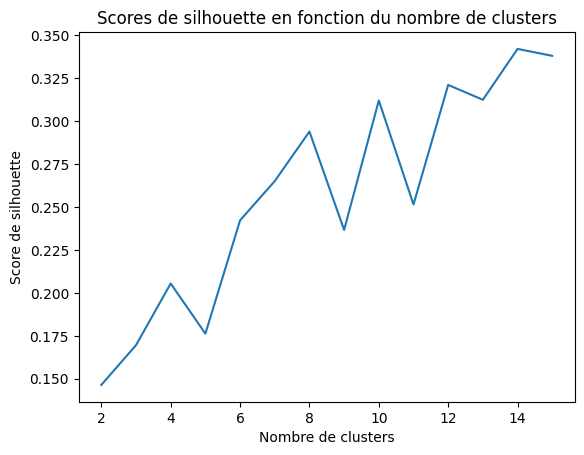

Le nombre optimal de clusters est : 14


In [18]:
X_std = X_1.copy()

# Calcul du score de silhouette pour chaque valeur de n_clusters comprise entre 2 et 15
n_clusters_range = range(2, 16)
scores = []

columns = X_std.columns

for n_clusters in n_clusters_range:
    # Initialisation de KMeans avec kmeans++
    
    #kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, max_iter=300, random_state=42)
    #kmeans.fit(X_std)
    #labels = kmeans.labels_
    #score = silhouette_score(X_std, labels)
    #print(f'Kmeans sil score : {score}')
    #scores.append(score)

    # Initialisation de MiniBatchKMeans
    mbkmeans = MiniBatchKMeans(n_clusters=n_clusters, init='k-means++', n_init=10, max_iter=300, batch_size=100, random_state=42)
    mbkmeans.fit(X_std)
    labels_mb = mbkmeans.labels_
    score_mb = silhouette_score(X_std, labels_mb)
    print(f'BatchKmeans {n_clusters} clusters, sil score : {score_mb}')
    scores.append(score_mb)

# Tracé du graphique des scores de silhouette
plt.plot(n_clusters_range, scores)
plt.xlabel('Nombre de clusters')
plt.ylabel('Score de silhouette')
plt.title('Scores de silhouette en fonction du nombre de clusters')
plt.show()

# Sélection de la valeur de n_clusters qui donne le score de silhouette le plus élevé
best_score = max(scores)
best_index = scores.index(best_score)
best_n_clusters = best_index + 2

print(f"Le nombre optimal de clusters est : {best_n_clusters}")

In [19]:
inertia = {}
dict_kmeans = {}
for k in range(1,25):
    print(k)
    kmeans = KMeans(n_clusters=k,
                   verbose=1,
                   random_state=0
                   ).fit(X_std)
    inertia[k] = kmeans.inertia_
    dict_kmeans[k] = kmeans

1
Initialization complete
Iteration 0, inertia 519397.2620159691.
Iteration 1, inertia 429315.00000000035.
Converged at iteration 1: strict convergence.
2
Initialization complete
Iteration 0, inertia 486549.0741656507.
Iteration 1, inertia 399916.03625812405.
Iteration 2, inertia 399898.7570772617.
Converged at iteration 2: strict convergence.
3
Initialization complete
Iteration 0, inertia 419199.7435652388.
Iteration 1, inertia 380238.1646320571.
Iteration 2, inertia 374724.83084305463.
Iteration 3, inertia 370247.2240892641.
Iteration 4, inertia 367877.4538688474.
Iteration 5, inertia 367050.9436791923.
Iteration 6, inertia 366883.56252250524.
Iteration 7, inertia 366839.60393350467.
Iteration 8, inertia 366827.71044406056.
Iteration 9, inertia 366825.98254029645.
Converged at iteration 9: center shift 6.689433601684459e-06 within tolerance 9.374999999999088e-05.
4
Initialization complete
Iteration 0, inertia 390865.9471329727.
Iteration 1, inertia 351671.88387655606.
Iteration 2, in

<AxesSubplot:title={'center':'Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters'}>

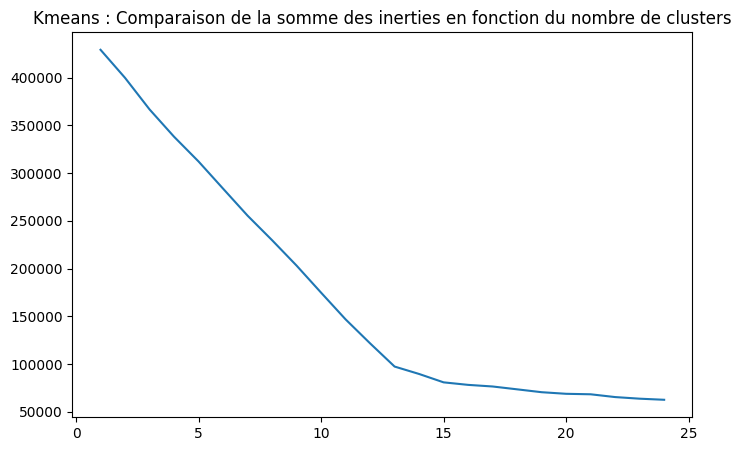

In [20]:
plt.figure(figsize=(8,5))
plt.title('Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters')
sns.lineplot(x=list(inertia.keys()),
             y=list(inertia.values())
            )

### Train and compare through time

In [21]:
clusters_num = 4


kmeans_X_6 = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(X_6)
kmeans_X_5 = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(X_5)
kmeans_X_4 = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(X_4)
kmeans_X_3 = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(X_3)
kmeans_X_2 = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(X_2)
kmeans_X_1 = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(X_1)

Initialization complete
Iteration 0, inertia 1224749.8328018046.
Iteration 1, inertia 1111289.2175830114.
Iteration 2, inertia 1111288.4782577113.
Converged at iteration 2: strict convergence.
Initialization complete
Iteration 0, inertia 1123797.1470793341.
Iteration 1, inertia 949787.9920593341.
Iteration 2, inertia 949034.9276971163.
Converged at iteration 2: strict convergence.
Initialization complete
Iteration 0, inertia 909446.2638279678.
Iteration 1, inertia 798870.9527088312.
Iteration 2, inertia 798868.9726091337.
Converged at iteration 2: strict convergence.
Initialization complete
Iteration 0, inertia 747013.4301411688.
Iteration 1, inertia 661234.8223744857.
Iteration 2, inertia 658170.301768308.
Iteration 3, inertia 657335.4919494115.
Iteration 4, inertia 656967.6485778537.
Iteration 5, inertia 656772.771113112.
Iteration 6, inertia 656528.5952547264.
Iteration 7, inertia 656155.4654023438.
Iteration 8, inertia 655680.6424934017.
Iteration 9, inertia 655350.6399893591.
Iter

# Compute ARI

In [22]:
adjusted_rand_score(kmeans_X_2.labels_, kmeans_X_1.predict(X_2))

0.8821333074985457

In [23]:
adjusted_rand_score(kmeans_X_3.labels_, kmeans_X_1.predict(X_3))

0.025032930564086106

In [24]:
ari0 = adjusted_rand_score(kmeans_X_1.labels_, kmeans_X_1.labels_)
ari1 = adjusted_rand_score(kmeans_X_2.labels_, kmeans_X_1.predict(X_2))
ari2 = adjusted_rand_score(kmeans_X_3.labels_, kmeans_X_1.predict(X_3))
ari3 = adjusted_rand_score(kmeans_X_4.labels_, kmeans_X_1.predict(X_4))
ari4 = adjusted_rand_score(kmeans_X_5.labels_, kmeans_X_1.predict(X_5))
ari5 = adjusted_rand_score(kmeans_X_6.labels_, kmeans_X_1.predict(X_6))

In [26]:
scores = [ari0, ari1, ari2, ari3, ari4, ari5]
periodes = ['Période 0', 'Période 1', 'Période 2', 'Période 3', 'Période 4', 'Période 5']

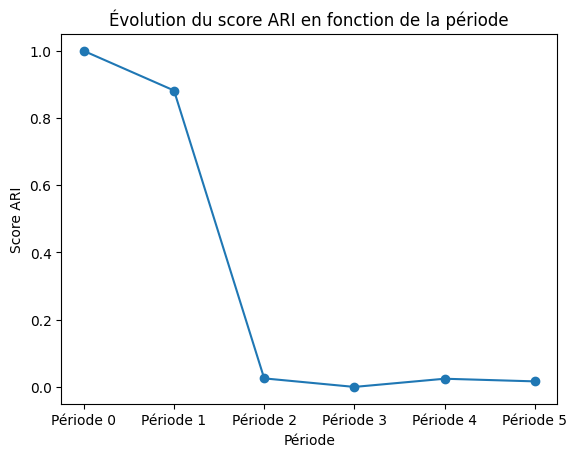

In [27]:
plt.plot(periodes, scores, marker='o')
plt.xlabel('Période')
plt.ylabel('Score ARI')
plt.title('Évolution du score ARI en fonction de la période')
plt.show()